In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import random
import matplotlib.pyplot as plt
import pickle
import mmap
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import transformers
from transformers import AutoTokenizer
print(device)
block_size = 64
batch_size = 128
eval_iters = 3000
max_iters = 30000
n_embd = 384
n_layer = 8
n_head = 8
l_rate = 3e-4
dropout = 0.3
vocab_size = 30522
num_merges = 20

cuda


In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
chars = ""
#Open the dataset and extract unqiue characters
df_read_train = pd.read_parquet("text_train.parquet")
df_read_val = pd.read_parquet("text_val.parquet")
print(df_read_val.columns)

Index(['text'], dtype='str')


In [4]:
tok = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast = True) 
print("Fast tokenizer?", isinstance(tok, transformers.PreTrainedTokenizerFast))
encode = lambda s : tok.encode(s)
decode = lambda s : tok.decode(s, skip_special_tokens = True)

Fast tokenizer? True


In [10]:
tokens_train = []
tokens_val = []
max_len = 64  # block size

# Tokenize training file
for i, line in enumerate(df_read_train['text']):
    if line.strip() == "":
        continue
    line_tokens = encode(line)
    # Break the line into 64-token chunks
    for j in range(0, len(line_tokens), max_len):
        tokens_train.extend(line_tokens[j : j + max_len])
    if i % 10000 == 0:
        print(f"Processed {i} lines, current token length: {len(tokens_train)}")

train_data = torch.tensor(tokens_train, dtype=torch.long)
print("Training data encoded, shape:", train_data.shape)

# Tokenize validation file
for i, line in enumerate(df_read_val['text']):
    if line.strip() == "":
        continue
    line_tokens = encode(line)
    # Break the line into 64-token chunks
    for j in range(0, len(line_tokens), max_len):
        tokens_val.extend(line_tokens[j : j + max_len])
    if i % 1000 == 0:
        print(f"Processed {i} lines, current token length: {len(tokens_val)}")

val_data = torch.tensor(tokens_val, dtype=torch.long)
print("Validation data encoded, shape:", val_data.shape)

Processed 0 lines, current token length: 39
Processed 10000 lines, current token length: 290490
Processed 20000 lines, current token length: 580179
Processed 30000 lines, current token length: 870461
Processed 40000 lines, current token length: 1159525
Processed 50000 lines, current token length: 1450001
Processed 60000 lines, current token length: 1741893
Processed 70000 lines, current token length: 2033967
Processed 80000 lines, current token length: 2324014
Processed 90000 lines, current token length: 2612356
Processed 100000 lines, current token length: 2901682
Processed 110000 lines, current token length: 3190713
Processed 120000 lines, current token length: 3480234
Processed 130000 lines, current token length: 3769182
Processed 140000 lines, current token length: 4058449
Processed 150000 lines, current token length: 4347367
Processed 160000 lines, current token length: 4638741
Processed 170000 lines, current token length: 4929768
Processed 180000 lines, current token length: 5219

In [5]:
train_data = torch.load("train_data.pt")
val_data = torch.load("val_data.pt")
print("Data loaded")

Data loaded


In [6]:

#Initizalized a function to get batches
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = data[ix.unsqueeze(1) + torch.arange(block_size)]
    y = data[ix.unsqueeze(1) + torch.arange(1,block_size + 1)]
    #Pin to memory for quicker cpu-gpu transfer
    x, y = x.pin_memory(), y.pin_memory()
    x, y = x.to(device, non_blocking = True),y.to(device, non_blocking = True)
    return x,y
x,y = get_batch('train')
print(f'inputs {x} and \n targets are {y}')
    

inputs tensor([[ 2571, 22601,  4475,  ...,  1997,  2068,  2064],
        [ 2027,  5121,  2079,  ...,  6438,  1997,  4023],
        [11311,  3001,  2024,  ...,  2025,  1012,   102],
        ...,
        [ 2008,  2024,  2328,  ...,  2000,  1996,  3493],
        [ 2126,  2000,  5468,  ...,  2155,  1010,  2000],
        [ 7099,  1012,   102,  ...,  2537,  1010, 15836]], device='cuda:0') and 
 targets are tensor([[22601,  4475,  1012,  ...,  2068,  2064,  2022],
        [ 5121,  2079, 11494,  ...,  1997,  4023,  1010],
        [ 3001,  2024,  3391,  ...,  1012,   102,   101],
        ...,
        [ 2024,  2328,  2005,  ...,  1996,  3493, 20557],
        [ 2000,  5468,  7715,  ...,  1010,  2000,  3305],
        [ 1012,   102,   101,  ...,  1010, 15836,  1998]], device='cuda:0')


In [7]:
#This makes computation faster by disabling the gradient from being tracked
@torch.no_grad()
def estimate_loss():
    out = {}
    #Sets the model in eval mode which stops dropout and something else I think
    model.eval()
    for split in ['train','val']:
        #Sets a 1d array of zeros to calculate the loss
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            #Gets data to evaluate the model on
            X,Y = get_batch(split)
            #Runs the foward pass and gets the logits and loss, I dont thinkw e need the logits though
            with autocast(device_type='cuda', dtype = torch.float16):
                logits,loss = model(X,Y)
            #Appends the item to the losses and item makes it into a decimal from a tensor I think
            losses[k] = loss.item()
        out[split] = losses.mean()
    #Puts the model back in training mode
    model.train()
    return out

In [8]:
class Head(nn.Module):
    def __init__(self,head_size):
        #Head size is basically how much info do we want these heads to store
        super().__init__()
        #initalize the K, Q, V needed for multihead attention
        self.key = nn.Linear(n_embd, head_size, bias = False)
        self.query = nn.Linear(n_embd, head_size, bias = False)
        self.value = nn.Linear(n_embd, head_size, bias = False)
        #Prevents the model from looking into future tokens by making the attention score zero
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        #Dropout neurons to prevevnt overfitting
        self.dropout = nn.Dropout(dropout)

    def forward(self,x):
        #Gets B T C from x.shape in other words the index in better words the information of the context
        B,T,C = x.shape
        k = self.key(x)
        q = self.query(x)
        #Dot Product of B and Q idk why excatly but transpose essentially idk what that does either, and k[-1] just gets the last element which idk why also and then square root I think thats just the formula
        wei = q @ k.transpose(-2,-1) * k.shape[-1] ** -0.5
        #This is to keep the model from cheating, Idk really know how other than it makes things into zeros and then the next row has one less zero , also dont know why float is inf and why it sets it equal to 0, T is just like the length of the word i suppose and Idk why it does that
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))
        #I thought you do nn.linear then softmax but yk whatever Softmax essentially just turns it into probabilities
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v =self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    def __init__(self,num_heads, head_size):
        super().__init__()
        #So basically ModuleList makes this run parellel for computation, and idk where Head(head_size) comes from. But it does this for the number of heads
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        # I think this is where you add and norm
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)
    def forward(self,x):
        #Adds the heads to each other into one vector, dim-1 focuses on the last array I think, I dont know why though
        out = torch.cat([h(x) for h in self.heads], dim =-1)
        #I dont know why it doesnt do droupout But its dropping out some nuerons
        out = self.dropout(self.proj(out))
        return out
class FeedForward(nn.Module):
    def __init__(self,n_embd):
        super().__init__()
        # Right so these are the 4 layers of encoding where the model learns
        self.net = nn.Sequential(
            #Add and norm
            nn.Linear(n_embd, 4* n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
        #However I thought the encoding process meant dotproduct attention and all that stuff
    def forward(self,x):
        #Basically just running it
        return self.net(x)
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
    def forward(self,x):
        y = self.sa(x)
        x = self.ln1(x+y)
        y = self.ffwd(x)
        x = self.ln2(x+y)
        return x
    

class TransformerLanguageModel(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
        #Makes the token embedding table
        self.token_embedding_table = nn.Embedding(vocab_size,n_embd)
        #Makes the position embedding table / embedding+position embedding
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        #Makes the 4 layers of decoding
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        #idk a fun ction for the final layer of the encoding
        self.ln_f = nn.LayerNorm(n_embd) # final layer 
        self.lm_head = nn.Linear(n_embd,vocab_size) #Linear then to softmax for probability
         #Gives itself weights that are learnable
        self.apply(self._init_weights)
    def _init_weights(self,module):
        if isinstance(module,nn.Linear):
            #Gives itself the weight and makes it so they all have a mean of 0.0 while the stadndard deviation how much the model can deviate to represent meaning is 0.02
            torch.nn.init.normal_(module.weight,mean = 0.0, std = 0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean = 0.0, std = 0.02)
    def forward(self,index,targets = None):
        B , T = index.shape
        tok_emb = self.token_embedding_table(index)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        if targets is None:
            loss = None
        else:
            B , T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss
    def generate(self,index,max_new_tokens):
        #index is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            #get the predictions
            index_cond = index[:, -block_size:]
            logits, loss = self.forward(index_cond)
            #focus only on hte last time step
            logits = logits[:,-1,:]
            #apply softmax to get probabilities
            probs = F.softmax(logits,dim=-1) # (B,C)
            #sample from the distribution
            index_next = torch.multinomial(probs,num_samples=1) # (B,1)
            #append sampled index to the running sequence
            index = torch.cat((index,index_next), dim=1) #(B,T+1)

        return index

with open("model-01.pkl","rb") as f:
    model = pickle.load(f)
m= model.to(device)
context = torch.zeros((1,1), dtype= torch.long, device = device)
generated_chars = decode(m.generate(context,max_new_tokens=100)[0].tolist())
print(generated_chars)
            

, cabinet, and plebeian, a supercooling astounding spiritual power in cultural and regional religions. still, the jewish philosopher socrates had stated a mind of the many good - working minds as well, resulting in resonance which both added proof and tested the theory for earthquake and earthquakes. avoid contact with social and environmental costs and find an association between contextual and environmental pollution. they are made out of a wide variety of gemstones or plastic, and


Iteration is 0, and the loss for training is 4.040422439575195, while the loss for validation is 4.183009624481201
Iteration is 3000, and the loss for training is 4.00137186050415, while the loss for validation is 4.15804386138916
Iteration is 6000, and the loss for training is 3.9641213417053223, while the loss for validation is 4.134400367736816
Iteration is 9000, and the loss for training is 3.933034896850586, while the loss for validation is 4.113468170166016
Iteration is 12000, and the loss for training is 3.9119036197662354, while the loss for validation is 4.102259635925293
Iteration is 15000, and the loss for training is 3.889832019805908, while the loss for validation is 4.087494373321533
Iteration is 18000, and the loss for training is 3.8696370124816895, while the loss for validation is 4.079987525939941
Iteration is 21000, and the loss for training is 3.8533313274383545, while the loss for validation is 4.069232940673828
Iteration is 24000, and the loss for training is 3.83

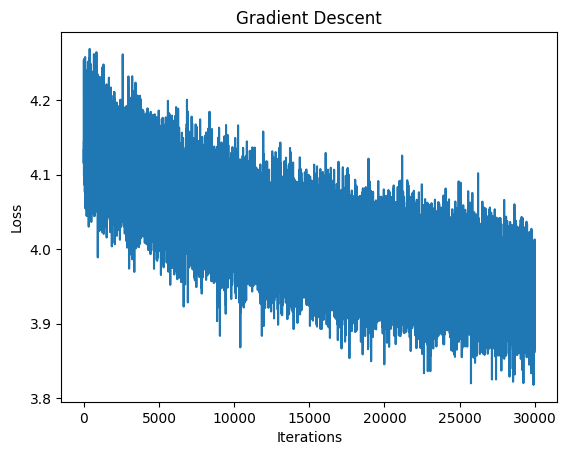

In [9]:
optimizer = torch.optim.AdamW(model.parameters(),lr=l_rate)
scaler = GradScaler()
losses = []
for iter in range(max_iters):
    if iter % eval_iters == 0:
       l_2 = estimate_loss()
       print(f"Iteration is {iter}, and the loss for training is {l_2['train']}, while the loss for validation is {l_2['val']}")
    if iter % 3000:
        with open('model-01.pkl', 'wb') as f:
            pickle.dump(model,f)
    #get the training batch
    xb,yb = get_batch('train')
    for param in model.parameters():
        param.grad = None
    #Get logits and the loss
    with autocast(device_type=device, dtype=torch.float16):
        logits,loss = model(xb,yb)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    losses.append(loss.item())
print(loss.item())
plt.plot(losses) 
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Gradient Descent')
plt.show()

In [13]:
context = torch.tensor(encode(input("Enter a random sentence, but stop mid way")), dtype = torch.long,device = device).unsqueeze(0)
generated_char = model.generate(context, max_new_tokens = 50)
print(decode(generated_char))

Enter a random sentence, but stop mid way Im confused about


["im confused about barack obama ' s plan — the word for the promise — is based on common belief. to generate the ' government will be able to give the president or congress particular chance to take over a democratic government, such as the president ' s"]
